## Формулировка задачи

Найти приближённое решение смешанной краевой задачи для неоднородного уравнения теплопроводности. 
Для расчёта решения использовать симметричную схему Кранка – Николсон. 

Исходное уравнение

$$
u_t = \frac{\partial}{\partial x} \left( \chi(x) \frac{\partial u}{\partial x} \right) + f(x, t), 
\quad x \in [x_{\min}, x_{\max}], \quad t \in (0, T]
$$

### Постановка задачи 

$$
\begin{cases}
u_t = \frac{\partial}{\partial x} \left( \chi(x) \frac{\partial u}{\partial x} \right) + f(x, t), \quad \chi(x) = 1.0, \quad x \in [-10, 10], \quad t \in (0, 1], \\
u(x, 0) = \phi(x) = \cos(0.3x), \\
u(-10, t) = \mu_1(t) = e^{-t} \cos(3), \\
u(10, t) = \mu_2(t) = e^{-t} \cos(3),
\end{cases}
$$

### Точное решение и источник

**Точное решение**:

$$
u_0(x, t) = e^{-t} \cos(0.3x)
$$

**Источник** $f(x, t)$:
$$
f(x, t) = e^{-t} \cos(kx) \cdot (-0.91)
$$

### Численная схема Кранка – Николсон

На равномерной сетке 
$$
x_i = x_{\min} + i h, \quad i = 0, \dots, N_x, \qquad 
t^n = n \tau, \quad n = 0, \dots, N_t,
$$
где $h = (x_{\max} - x_{\min}) / N_x$, $\tau = T / N_t$, 
схема записывается в виде:

$$
\frac{u_i^{n+1} - u_i^n}{\tau} = 
\frac{1}{2} \Bigl[ \Lambda u_i^{n+1} + \Lambda u_i^n \Bigr] + f_i^{n+1/2},
$$

где разностный оператор:

$$
\Lambda u_i = \frac{1}{h^2} \Bigl[ 
    \chi_{i+1/2} (u_{i+1} - u_i) - \chi_{i-1/2} (u_i - u_{i-1})
\Bigr], 
\qquad 
\chi_{i+1/2} = \frac{\chi_i + \chi_{i+1}}{2},
$$

$f_i^{n+1/2} = \frac{1}{2} \bigl[ f(x_i, t^n) + f(x_i, t^{n+1}) \bigr]$.

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
def solve_heat_cn_full(x_min, x_max, t_max, Nx, Nt, chi_func, f_func, phi_func,
                       bc_left=None, bc_right=None, save_history=True):
    h = (x_max - x_min) / Nx
    tau = t_max / Nt
    x = np.linspace(x_min, x_max, Nx + 1)
    t = np.linspace(0, t_max, Nt + 1)
    
    chi = chi_func(x)
    chi_half = 0.5 * (chi[:-1] + chi[1:]) 
    
    u = phi_func(x).copy()
    u_new = np.zeros_like(u)
    
    if bc_left:
        u[0] = bc_left(0)
    if bc_right:
        u[-1] = bc_right(0)
    
    r = tau / (2.0 * h * h)
    
    a = np.zeros(Nx + 1)
    b = np.zeros(Nx + 1)
    c = np.zeros(Nx + 1)
    d = np.zeros(Nx + 1)
    
    for i in range(1, Nx):
        alpha = r * chi_half[i-1]
        beta = r * chi_half[i]
        a[i] = -alpha
        b[i] = 1.0 + alpha + beta
        c[i] = -beta
        
    b[0] = 1.0
    c[0] = 0.0
    a[Nx] = 0.0
    b[Nx] = 1.0
    
    if save_history:
        U_history = [u.copy()]
    else:
        U_history = None
    
    for n in range(Nt):
        t_curr = n * tau
        t_next = (n + 1) * tau
        
        d[:] = 0.0
        
        for i in range(1, Nx):
            alpha = r * chi_half[i-1]
            beta = r * chi_half[i]
            f_val = 0.5 * (f_func(x[i], t_curr) + f_func(x[i], t_next))
            rhs = alpha * u[i-1] + (1.0 - alpha - beta) * u[i] + beta * u[i+1] + tau * f_val
            d[i] = rhs
        
        bcL = bc_left(t_next) if bc_left else 0.0
        bcR = bc_right(t_next) if bc_right else 0.0
        
        # Перенос известных ГУ в правую часть
        if bc_left:
            d[1] += r * chi_half[0] * bcL
        if bc_right:
            d[Nx-1] += r * chi_half[Nx-1] * bcR
        
        d[0] = bcL
        d[Nx] = bcR
        
        # Метод прогонки
        A = a[1:Nx].copy()
        B = b[1:Nx].copy()
        C = c[1:Nx].copy()
        D = d[1:Nx].copy()
        
        for i in range(1, Nx - 1):
            m = A[i] / B[i-1]
            B[i] = B[i] - m * C[i-1]
            D[i] = D[i] - m * D[i-1]
            
        u_new[Nx-1] = D[Nx-2] / B[Nx-2]
        for i in range(Nx-3, -1, -1):
            u_new[i+1] = (D[i] - C[i] * u_new[i+2]) / B[i]
            
        u_new[0] = bcL
        u_new[Nx] = bcR
        
        u[:] = u_new[:]
        
        if save_history:
            U_history.append(u.copy())
    
    if save_history:
        return x, t, np.array(U_history)
    else:
        return x, u, t_next

In [ ]:
def solve_heat_cn_weighted(x_min, x_max, t_max, Nx, Nt, chi_func, f_func, phi_func,
                           bc_left=None, bc_right=None, nu=0.5):
    """
    nu=0.5 — Кранк-Николсон
    nu=1.0 — полностью неявная
    nu=0.0 — явная
    nu=0.25 — промежуточная схема
    """
    h = (x_max - x_min) / Nx
    tau = t_max / Nt
    x = np.linspace(x_min, x_max, Nx + 1)
    t = np.linspace(0, t_max, Nt + 1)
    
    chi = chi_func(x)
    chi_max = np.max(chi)
    chi_half = 0.5 * (chi[:-1] + chi[1:])
    
    # Проверка условия Куранта
    r = tau / (h * h)
    courant_number = r * chi_max  # Число Куранта
    
    if nu < 0.5:
        if nu == 0.0:
            # tau * chi_max / h^2 <= 0.5
            courant_limit = 0.5
        else:
            courant_limit = 1.0 / (2.0 * (1.0 - 2.0 * nu))
        
        if courant_number > courant_limit:
            raise ValueError(
                f"Нарушено условие Куранта\n"
                f"Число Куранта: {courant_number:.4f}\n")
    
    u = phi_func(x).copy()
    u_new = np.zeros_like(u)
    
    a = np.zeros(Nx + 1)
    b = np.zeros(Nx + 1)
    c = np.zeros(Nx + 1)
    d = np.zeros(Nx + 1)
    
    for i in range(1, Nx):
        alpha = nu * r * chi_half[i-1]
        beta = nu * r * chi_half[i]
        a[i] = -alpha
        b[i] = 1.0 + alpha + beta
        c[i] = -beta
    
    b[0] = 1.0
    c[0] = 0.0
    a[Nx] = 0.0
    b[Nx] = 1.0
    
    U_history = [u.copy()]
    
    for n in range(Nt):
        t_curr = n * tau
        t_next = (n + 1) * tau
        t_mid = t_curr + nu * tau  # Время источника
        
        d[:] = 0.0
        
        for i in range(1, Nx):
            alpha_impl = nu * r * chi_half[i-1]
            beta_impl = nu * r * chi_half[i]
            alpha_expl = (1 - nu) * r * chi_half[i-1]
            beta_expl = (1 - nu) * r * chi_half[i]
            
            # Явная часть (старый слой)
            explicit_part = alpha_expl * u[i-1] + (1 - alpha_expl - beta_expl) * u[i] + beta_expl * u[i+1]
            
            # Неявная часть (новый слой) — переносим в левую часть
            f_val = f_func(x[i], t_mid)
            d[i] = explicit_part + tau * f_val
        
        bcL = bc_left(t_next) if bc_left else 0.0
        bcR = bc_right(t_next) if bc_right else 0.0
        
        if bc_left:
            d[1] += nu * r * chi_half[0] * bcL
        if bc_right:
            d[Nx-1] += nu * r * chi_half[Nx-1] * bcR
        
        d[0] = bcL
        d[Nx] = bcR
        
        # Метод прогонки
        A = a[1:Nx].copy()
        B = b[1:Nx].copy()
        C = c[1:Nx].copy()
        D = d[1:Nx].copy()
        
        for i in range(1, Nx - 1):
            m = A[i] / B[i-1]
            B[i] = B[i] - m * C[i-1]
            D[i] = D[i] - m * D[i-1]
        
        u_new[Nx-1] = D[Nx-2] / B[Nx-2]
        for i in range(Nx-3, -1, -1):
            u_new[i+1] = (D[i] - C[i] * u_new[i+2]) / B[i]
        
        u_new[0] = bcL
        u_new[Nx] = bcR
        
        u[:] = u_new[:]
        U_history.append(u.copy())
    
    return x, t, np.array(U_history)

In [53]:
def compare_nu_values():
    x_min, x_max = -10.0, 10.0
    t_max = 1.0
    Nx, Nt = 100, 150
    k = 0.3
    
    def u_exact(x, t):
        return np.exp(-t) * np.cos(k * x)
    
    def chi_test(x):
        return np.ones_like(x)
    
    def f_test(x, t):
        u = np.exp(-t) * np.cos(k * x)
        return -u - (-k**2 * u)
    
    def phi_test(x):
        return u_exact(x, 0)
    
    def bc_left(t):
        return u_exact(x_min, t)
    
    def bc_right(t):
        return u_exact(x_max, t)
    
    nu_values = [0.0, 0.5, 1.0]
    print(f"{'ν':>6} | {'L2':>12} | {'L∞':>12}")
    
    fig, axes = plt.subplots(1, len(nu_values), figsize=(15, 5))
    if len(nu_values) == 1:
        axes = [axes]
    axes = axes.flatten()
    
    for idx, nu in enumerate(nu_values):
        x, t, U = solve_heat_cn_weighted(x_min, x_max, t_max, Nx, Nt,
                                        chi_test, f_test, phi_test,
                                        bc_left=bc_left, bc_right=bc_right,
                                        nu=nu)
        
        u_num = U[-1, :]
        u_true = u_exact(x, t_max)
        error = np.abs(u_num - u_true)
        
        err_L2 = np.sqrt(np.trapezoid(error**2, x))
        err_Linf = np.max(error)
        
        print(f"{nu:>6.1f} | {err_L2:>12.2e} | {err_Linf:>12.2e}")
        
        axes[idx].plot(x, u_num, 'b-', linewidth=2, label='Численное')
        axes[idx].plot(x, u_true, 'r--', linewidth=2, label='Точное')
        axes[idx].fill_between(x, u_num, u_true, alpha=0.3, label='Ошибка')
        axes[idx].set_xlabel('x')
        axes[idx].set_ylabel('u')
        axes[idx].set_title(f'ν = {nu}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('images/compare_nu_values.png')
    plt.show()

In [54]:
def plot_convergence_order():
    x_min, x_max = -10.0, 10.0
    t_max = 1.0
    
    k = 0.3
    def u_exact(x, t):
        return np.exp(-t) * np.cos(k * x)
    
    def chi_test(x):
        return np.ones_like(x)
    
    def f_test(x, t):
        u = np.exp(-t) * np.cos(k * x)
        return -u - (-k**2 * u)
    
    def phi_test(x):
        return u_exact(x, 0)
    
    def bc_left(t):
        return u_exact(x_min, t)
    
    def bc_right(t):
        return u_exact(x_max, t)
    
    Nx_list = [40, 80, 160, 320]
    errors_L2 = []
    errors_Linf = []
    h_values = []
    
    print(f"{'Nx':>6} | {'h':>8} | {'L2':>12} | {'L∞':>12} | {'p_L2':>8} | {'p_L∞':>8}")
    
    for Nx in Nx_list:
        Nt = int(Nx * 1.5)
        h = (x_max - x_min) / Nx
        
        x, t, U = solve_heat_cn_full(x_min, x_max, t_max, Nx, Nt,
                                     chi_test, f_test, phi_test,
                                     bc_left=bc_left, bc_right=bc_right)
        
        u_num = U[-1, :]
        u_true = u_exact(x, t_max)
        
        error = np.abs(u_num - u_true)
        err_L2 = np.sqrt(np.trapezoid(error**2, x))
        err_Linf = np.max(error)
        
        errors_L2.append(err_L2)
        errors_Linf.append(err_Linf)
        h_values.append(h)
        
        if len(errors_L2) > 1:
            p_L2 = np.log(errors_L2[-2] / errors_L2[-1]) / np.log(2)
            p_Linf = np.log(errors_Linf[-2] / errors_Linf[-1]) / np.log(2)
        else:
            p_L2 = p_Linf = None
        
        p2_str = f"{p_L2:.2f}" if p_L2 else "—"
        p_inf_str = f"{p_Linf:.2f}" if p_Linf else "—"
        
        print(f"{Nx:>6} | {h:>8.4f} | {err_L2:>12.2e} | {err_Linf:>12.2e} | {p2_str:>8} | {p_inf_str:>8}")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.loglog(h_values, errors_L2, 'bo-', linewidth=2, markersize=8, label='L₂ ошибка')
    ax.loglog(h_values, errors_Linf, 'rs-', linewidth=2, markersize=8, label='L∞ ошибка')
    
    h_ref = h_values[0]
    ax.loglog(h_values, errors_L2[0] * (np.array(h_values) / h_ref)**2, 
              'b--', alpha=0.5, label='O(h²)')
    ax.loglog(h_values, errors_Linf[0] * (np.array(h_values) / h_ref)**2, 
              'r--', alpha=0.5)
    
    ax.set_xlabel('Шаг сетки h', fontsize=12)
    ax.set_ylabel('Ошибка', fontsize=12)
    ax.set_title('Порядок сходимости схемы Кранка-Николсон', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    
    if len(errors_L2) >= 2:
        p_est = np.log(errors_L2[0] / errors_L2[-1]) / np.log(h_values[0] / h_values[-1])
        ax.text(0.05, 0.95, f'Оценочный порядок: p ≈ {p_est:.2f}', 
                transform=ax.transAxes, fontsize=11,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('images/convergence_order.png')
    plt.show()

In [57]:
def compare_with_exact_3d():    
    x_min, x_max = -10.0, 10.0
    t_max = 1.0
    Nx, Nt = 100, 150
    
    k = 0.3
    def u_exact(x, t):
        return np.exp(-t) * np.cos(k * x)
    
    def chi_test(x):
        return np.ones_like(x)
    
    def f_test(x, t):
        u = np.exp(-t) * np.cos(k * x)
        return -u - (-k**2 * u)
    
    def phi_test(x):
        return u_exact(x, 0)
    
    def bc_left(t):
        return u_exact(x_min, t)
    
    def bc_right(t):
        return u_exact(x_max, t)
    
    # Получаем решение с историей
    x, t, U = solve_heat_cn_full(x_min, x_max, t_max, Nx, Nt,
                                 chi_test, f_test, phi_test,
                                 bc_left=bc_left, bc_right=bc_right)
    
    X, T = np.meshgrid(x, t)
    U_exact = u_exact(X, T)
    U_error = np.abs(U - U_exact)
    # print(f"Максимальная ошибка: {np.max(U_error):.6e}")
    
    fig = plt.figure(figsize=(18, 12))
    
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(X, T, U, cmap='viridis', alpha=0.9, edgecolor='none')
    ax1.set_xlabel('x', fontsize=10)
    ax1.set_ylabel('t', fontsize=10)
    ax1.set_zlabel('u_num', fontsize=10)
    ax1.set_title('Численное решение', fontsize=12, fontweight='bold')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
    
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(X, T, U_exact, cmap='viridis', alpha=0.9, edgecolor='none')
    ax2.set_xlabel('x', fontsize=10)
    ax2.set_ylabel('t', fontsize=10)
    ax2.set_zlabel('u_exact', fontsize=10)
    ax2.set_title('Точное решение', fontsize=12, fontweight='bold')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

    ax3 = fig.add_subplot(2, 2, 3)
    ax3.plot(x, U[0, :], 'r--', linewidth=2, label='Численное', alpha=0.7)
    ax3.plot(x, U_exact[0, :], 'b-', linewidth=2, label='Точное', alpha=0.7)
    ax3.fill_between(x, U[0, :], U_exact[0, :], alpha=0.3, color='green', label='Разность')
    ax3.set_xlabel('x', fontsize=11)
    ax3.set_ylabel('u', fontsize=11)
    ax3.set_title('Сравнение при t = 0', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(2, 2, 4)
    t_indices = [0, Nt//4, Nt//2, 3*Nt//4, Nt]
    colors = plt.cm.viridis(np.linspace(0, 1, len(t_indices)))
    for i, idx in enumerate(t_indices):
        ax4.plot(x, U[idx, :], '--', color=colors[i], alpha=0.7, label=f'num t={t[idx]:.1f}')
        ax4.plot(x, U_exact[idx, :], '-', color=colors[i], alpha=0.5)
    ax4.set_xlabel('x', fontsize=11)
    ax4.set_ylabel('u', fontsize=11)
    ax4.set_title('Профили решений', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('images/comparison_3d.png')
    plt.show()

    Nx |        h |           L2 |           L∞ |     p_L2 |     p_L∞
    40 |   0.5000 |     2.37e-04 |     8.73e-05 |        — |        —
    80 |   0.2500 |     5.93e-05 |     2.18e-05 |     2.00 |     2.00
   160 |   0.1250 |     1.48e-05 |     5.46e-06 |     2.00 |     2.00
   320 |   0.0625 |     3.71e-06 |     1.37e-06 |     2.00 |     2.00


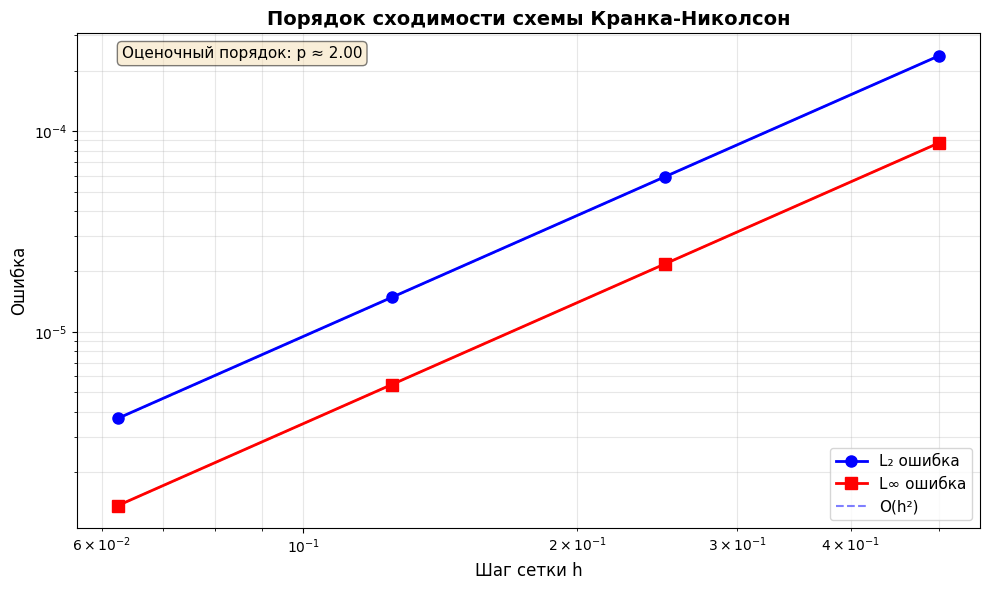

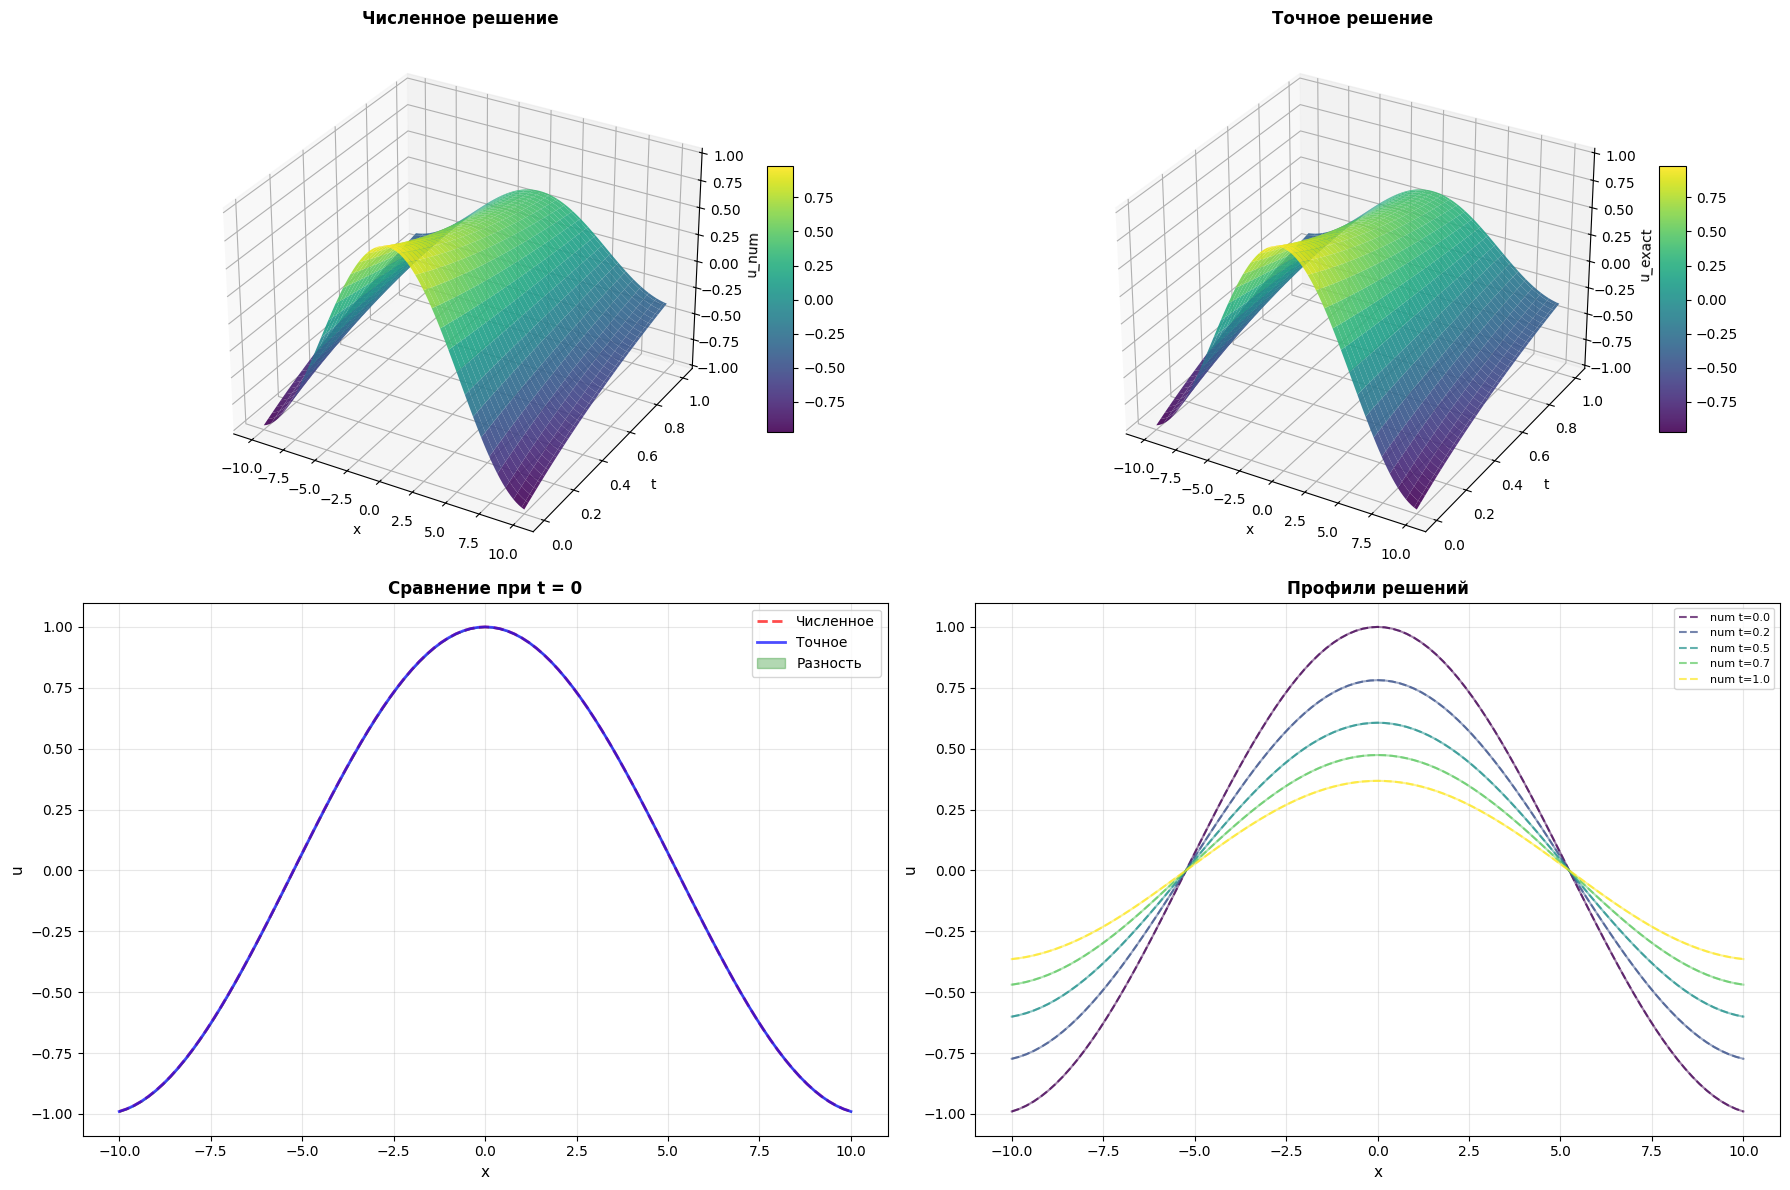

     ν |           L2 |           L∞
   0.0 |     5.40e-03 |     1.99e-03
   0.5 |     4.62e-05 |     1.70e-05
   1.0 |     5.47e-03 |     2.01e-03


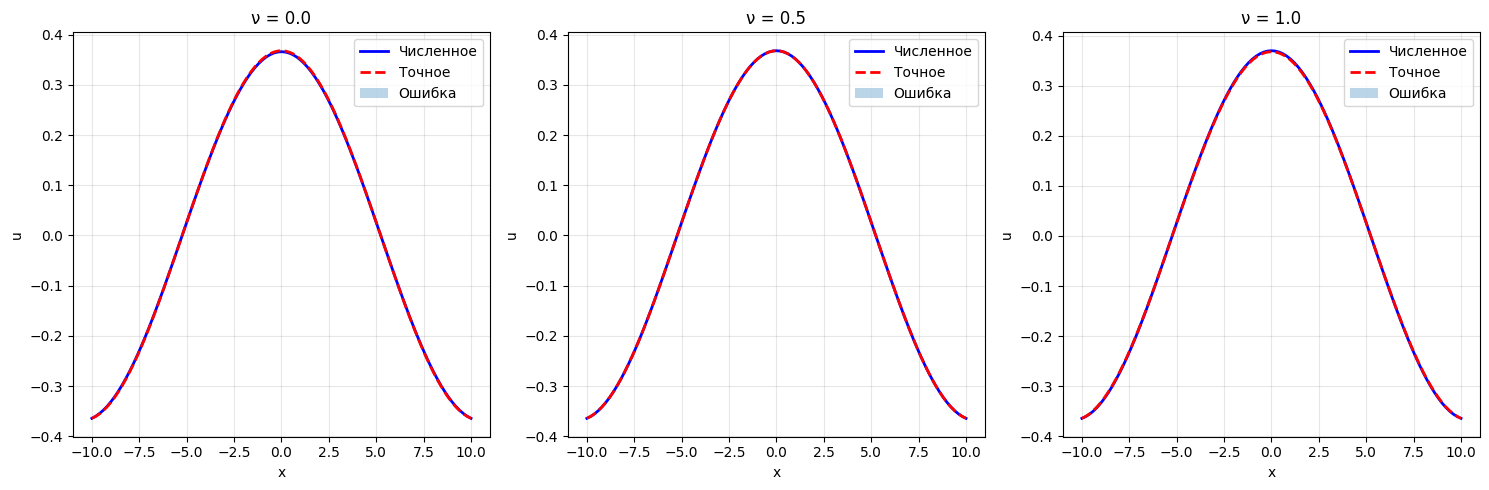

In [58]:
if __name__ == "__main__":
    plot_convergence_order()
    compare_with_exact_3d()
    compare_nu_values()